# Used Car Price Prediction

## Business Understanding

###  Business Context

The used car market is rapidly growing, especially in emerging markets like India. Consumers are becoming more value-conscious and want to make data-driven decisions before buying or selling vehicles. Pricing a used car accurately is a crucial factor in facilitating fair and transparent transactions. However, due to the diversity of car types, conditions, and features, pricing can be inconsistent and subjective.

This project explores historical data from the Indian used car market to uncover patterns and relationships between car features and their market value. By understanding these factors, we aim to provide actionable insights that can support individuals and businesses in the used car industry.



###  Problem Statement

Buyers and sellers often struggle to determine a fair selling price for used cars due to the variability in vehicle specifications, mileage, and other influencing factors. There is a need for a data-driven approach that analyzes historical car sales data to understand how different features influence pricing.



###  Objectives

#### Main Objective
- To analyze the factors influencing used car prices and provide insights for fair valuation.

#### Specific Objectives
- To assess how car age affects its market price.
- To evaluate the impact of mileage (kilometers driven) on pricing.
- To explore how fuel type, seller type, and transmission affect car value.
- To identify the most influential features in determining car prices.
- To present the findings using clear visualizations for non-technical stakeholders.



###  Success Metrics

- Quality and clarity of exploratory data analysis (EDA) outputs.
- Usefulness and interpretability of insights drawn from the dataset.
- Relevance of recommendations provided based on data patterns.
- Stakeholder understanding and acceptance of the insights.
- **Modeling performance**, including:
  - R² Score for regression models.
  - MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error) to evaluate prediction accuracy.
  - **Feature importance** to identify key factors that influence car prices.



###  Key Stakeholders

- **Car Buyers** – seeking to avoid overpaying for used vehicles.
- **Car Sellers/Dealers** – looking for data-backed justification for pricing.
- **Used Car Platforms** – aiming to enhance trust and transparency in listings.
- **Data Analysts** – interested in leveraging real-world automotive data for insights.


##  Data Understanding

### Data Overview

The dataset contains **4009 rows** and **12 columns** with the following features:

- **brand**: Car brand (e.g., Ford, Hyundai).
- **model**: Specific car model (e.g., Utility Police Interceptor Base, Palisade SEL).
- **model_year**: The year the car was manufactured.
- **milage**: The number of miles the car has been driven (as a string).
- **fuel_type**: Type of fuel the car uses (e.g., Gasoline, Diesel).
- **engine**: Engine details (e.g., 3.8L V6).
- **transmission**: Type of transmission (e.g., 8-Speed Automatic).
- **ext_col**: Exterior color of the car.
- **int_col**: Interior color of the car.
- **accident**: Indicates whether the car has been in an accident (e.g., None reported, At least 1 accident reported).
- **clean_title**: Indicates whether the car has a clean title (Yes/No).
- **price**: Price of the car (as a string with currency symbol).


### Basic Statistics

- **Model Year**: The dataset includes cars manufactured from **1974 to 2024**, with the average model year being **2015.5** and the median year being **2017**.
- The dataset is heavily skewed towards more recent model years (2012–2020).
  

### Missing Values

- **fuel_type**: 170 missing values (4.2% of the dataset).
- **accident**: 113 missing values (2.8%).
- **clean_title**: 596 missing values (14.9%).
  
These columns will require attention during the **data cleaning** phase.


### Unique Values

- **Brand**: 57 unique brands.
- **Model**: 1898 unique models, suggesting a large variety of cars.
- **Mileage**: 2818 unique values, indicating different formats (needs standardization).
- **Fuel Type**: 7 unique values, with some missing entries.
- **Engine**: 1146 unique entries, indicating various engine types.
- **Transmission**: 62 unique values, which is quite high.
- **Accident**: 2 unique values ("None reported", "At least 1 accident reported").
- **Clean Title**: 1 unique value (likely binary).
- **Price**: 1569 unique values, indicating a wide range of prices.

In [94]:
import pandas as pd

# Load the dataset
df = pd.read_csv('used_cars.csv')

# Display the first few rows of the dataset
df.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [95]:
# Check data types and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [96]:
# Basic statistics for numeric columns
df.describe()


,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [97]:
# Check for missing data
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [98]:
# Unique values in each column
df.nunique()

brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64

## Data Cleaning

In [99]:
# Drop unnecessary columns
df.drop(columns=['ext_col', 'int_col', 'clean_title'], inplace=True)

In [100]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,accident,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,At least 1 accident or damage reported,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,At least 1 accident or damage reported,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,None reported,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,None reported,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,None reported,"$34,999"


In [101]:
# Display unique values in the 'fuel_type' column
df['fuel_type'].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', nan, 'Diesel',
       'Plug-In Hybrid', '–', 'not supported'], dtype=object)

In [102]:
# Map specific fuel types to 'Petrol'
df['fuel_type'] = df['fuel_type'].replace({
    'Gasoline': 'Petrol',
    'E85 Flex Fuel': 'Petrol',
    'Hybrid': 'Petrol',
    'Plug-In Hybrid': 'Petrol'
})

In [103]:
# Filter rows with problematic fuel_type values
problematic_fuel = df[df['fuel_type'].isin(['–', 'not supported']) | df['fuel_type'].isna()]

# Display 30 random samples from the filtered rows
problematic_fuel.sample(n=10, random_state=42)


,brand,model,model_year,milage,fuel_type,engine,transmission,accident,price
3834,Ford,F-150 Lightning LARIAT,2022,470 mi.,NaN,563.0HP Electric Motor Electric Fuel System,1-Speed A/T,None reported,"$71,900"
3961,Tesla,Model 3 Long Range,2021,"23,749 mi.",NaN,Electric,1-Speed Automatic,None reported,"$35,999"
2677,Rivian,R1S Adventure Package,2023,542 mi.,NaN,835.0HP Electric Motor Electric Fuel System,A/T,None reported,"$92,500"
3383,Tesla,Model 3 Performance,2020,"45,468 mi.",NaN,455.0HP Electric Motor Electric Fuel System,1-Speed A/T,None reported,"$45,999"
321,Chevrolet,Bolt EUV Premier,2022,"7,624 mi.",NaN,Electric,1-Speed Automatic,None reported,"$31,985"
2116,Tesla,Model S P100D,2017,"103,000 mi.",NaN,Electric Motor Electric Fuel System,1-Speed A/T,None reported,"$36,000"
3427,Tesla,Model S 100D,2018,"83,424 mi.",NaN,518.0HP Electric Motor Electric Fuel System,1-Speed A/T,None reported,"$45,000"
1269,Dodge,Challenger R/T Scat Pack,2016,"7,928 mi.",–,–,6-Speed M/T,None reported,"$37,500"
3896,Tesla,Model Y Performance,2020,"27,500 mi.",NaN,455.0HP Electric Motor Electric Fuel System,A/T,None reported,"$44,000"
2770,Kia,Niro EV EX,2022,"20,000 mi.",NaN,201.0HP Electric Motor Electric Fuel System,1-Speed A/T,None reported,"$29,998"


In [104]:
# Define keywords that indicate electric vehicles
electric_keywords = ['Electric', 'Battery', 'Standard', 'kW']

# Update fuel_type to 'Electric' where engine contains any of the keywords and fuel_type is missing or problematic
df.loc[
    (df['fuel_type'].isna() | df['fuel_type'].isin(['–', 'not supported'])) &
    df['engine'].str.contains('|'.join(electric_keywords), case=False, na=False),
    'fuel_type'
] = 'Electric'

In [105]:
df['fuel_type'].unique()

array(['Petrol', 'Electric', 'Diesel', '–'], dtype=object)

In [106]:
# Drop rows where fuel_type is still '–'
df = df[df['fuel_type'] != '–']

In [107]:
# Display unique values in the 'accident' column
df['accident'].unique()

array(['At least 1 accident or damage reported', 'None reported', nan],
      dtype=object)

In [108]:
# Map textual values to 'Yes' and 'No'
df['accident'] = df['accident'].map({
    'At least 1 accident or damage reported': 'Yes',
    'None reported': 'No'
})

In [109]:
df['accident'].unique()

array(['Yes', 'No', nan], dtype=object)

In [110]:
# Drop rows with missing values in 'accident' column
df = df.dropna(subset=['accident'])

In [111]:
# Unique values in each column
df.nunique()

brand             57
model           1837
model_year        29
milage          2722
fuel_type          3
engine          1129
transmission      62
accident           2
price           1519
dtype: int64

In [112]:
df.shape

(3852, 9)

In [113]:
# Display unique values in the 'transmission' column
df['transmission'].unique()

array(['6-Speed A/T', '8-Speed Automatic', 'Automatic', '7-Speed A/T',
       'F', 'A/T', '8-Speed A/T', 'Transmission w/Dual Shift Mode',
       '9-Speed Automatic', '6-Speed M/T', '10-Speed A/T', '9-Speed A/T',
       '5-Speed A/T', '1-Speed A/T', 'Automatic CVT',
       '7-Speed Automatic with Auto-Shift', 'CVT-F',
       '6-Speed Automatic with Auto-Shift', 'M/T', '10-Speed Automatic',
       'CVT Transmission', '4-Speed A/T', '6-Speed Automatic',
       '4-Speed Automatic', '8-Speed Automatic with Auto-Shift',
       '5-Speed Automatic', '8-SPEED AT', '1-Speed Automatic',
       '5-Speed M/T', 'Manual', '6-Speed Manual', 'Variable', '2',
       '7-Speed Manual', 'Automatic, 9-Spd 9G-Tronic', 'Automatic, 8-Spd',
       'Automatic, 8-Spd Sport w/Sport & Manual Modes', '–',
       'Auto, 6-Spd w/CmdShft', 'Transmission Overdrive Switch',
       '7-Speed Automatic', 'Automatic, 8-Spd PDK Dual-Clutch',
       'Automatic, 8-Spd M STEPTRONIC w/Drivelogic, Sport & Manual Modes',
       'A

In [114]:
import numpy as np

# Convert all values to string and classify based on keywords
df['transmission'] = df['transmission'].astype(str).apply(lambda x: 
    'Manual' if any(keyword in x for keyword in ['M/T', 'Manual', 'M', '6-Spd', 'Mt']) 
    else ('Automatic' if any(keyword in x for keyword in ['A/T', 'Automatic', 'Dual', 'CVT', 'AT', 'Variable', 'Tronic', 'Auto', 'Cmd', 'Single-Speed', '10-Spd', '7-Speed', '2']) 
          else np.nan)
)

In [115]:
# Drop the nan
df = df.dropna(subset=['transmission'])

In [116]:
df['transmission'].value_counts()

Automatic    3101
Manual        738
Name: transmission, dtype: int64

In [117]:
# Remove 'mi.' and commas, then convert to integer
df['milage'] = df['milage'].str.replace('mi.', '', regex=False).str.replace(',', '', regex=False).astype(int)

In [118]:
# Remove '$' and commas, then convert to integer
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(int)


In [119]:
# Changing the column name 'milage' to 'mileage'
df.rename(columns={'milage': 'mileage'}, inplace=True)

In [120]:
# Summary including non-null counts and types
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3839 entries, 0 to 4008
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         3839 non-null   object
 1   model         3839 non-null   object
 2   model_year    3839 non-null   int64 
 3   mileage       3839 non-null   int32 
 4   fuel_type     3839 non-null   object
 5   engine        3839 non-null   object
 6   transmission  3839 non-null   object
 7   accident      3839 non-null   object
 8   price         3839 non-null   int32 
dtypes: int32(2), int64(1), object(6)
memory usage: 269.9+ KB


## Feature Engineering

In [121]:
# Calculating the car's age
import datetime
current_year = datetime.datetime.now().year
df['car_age'] = current_year - df['model_year']

In [122]:
df['engine_hp'] = df['engine'].str.extract(r'(\d{2,4}\.?\d*)HP').astype(float)

In [123]:
df['engine_L'] = df['engine'].str.extract(r'(\d\.\d+)L').astype(float)

In [124]:
df['is_electric'] = df['fuel_type'].apply(lambda x: 1 if 'Electric' in x else 0)

In [125]:
df.head()

,brand,model,model_year,mileage,fuel_type,engine,transmission,accident,price,car_age,engine_hp,engine_L,is_electric
0,Ford,Utility Police Interceptor Base,2013,51000,Petrol,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,Automatic,Yes,10300,12,300.0,3.7,0
1,Hyundai,Palisade SEL,2021,34742,Petrol,3.8L V6 24V GDI DOHC,Automatic,Yes,38005,4,NaN,3.8,0
2,Lexus,RX 350 RX 350,2022,22372,Petrol,3.5 Liter DOHC,Automatic,No,54598,3,NaN,NaN,0
3,INFINITI,Q50 Hybrid Sport,2015,88900,Petrol,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,Automatic,No,15500,10,354.0,3.5,0
4,Audi,Q3 45 S line Premium Plus,2021,9835,Petrol,2.0L I4 16V GDI DOHC Turbo,Automatic,No,34999,4,NaN,2.0,0


## Exploratory Data Analysis (EDA)

### 1. Univariate Analysis

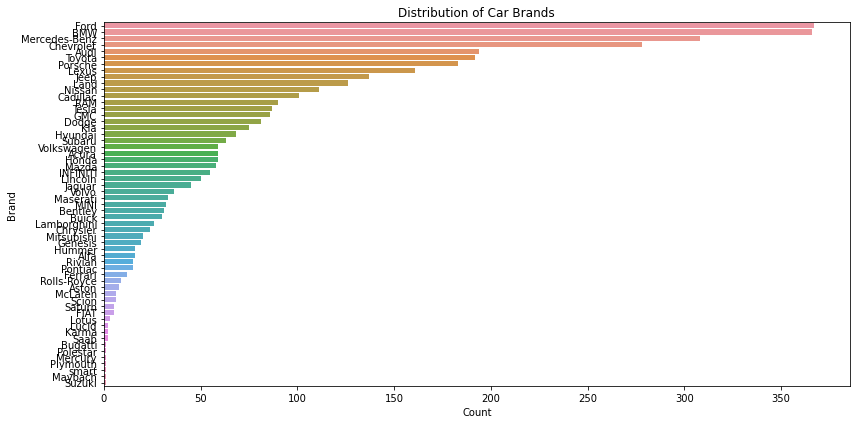

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
# Car brand distribution
plt.figure(figsize=(12,6))
sns.countplot(y='brand', data=df, order=df['brand'].value_counts().index)
plt.title('Distribution of Car Brands')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

- It shows that Ford is the most common brand, followed by BMW, Mercedes-Benz, Chevrolet, and Audi. 
- The dataset contains a diverse range of car brands, including luxury brands like Rolls-Royce, McLaren, and Lamborghini, as well as mass-market brands like Toyota, Honda, and Hyundai.

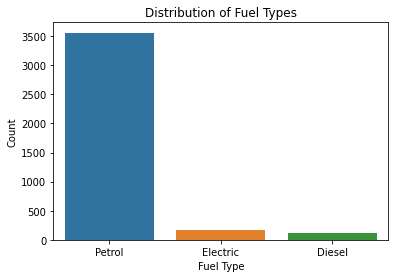

In [127]:
sns.countplot(x='fuel_type', data=df)
plt.title('Distribution of Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.show()

- Petrol is the dominant fuel type.

- Electric and Diesel cars make up a small percentage.

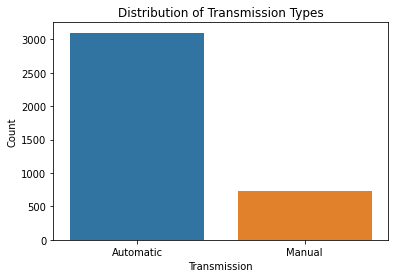

In [128]:
sns.countplot(x='transmission', data=df)
plt.title('Distribution of Transmission Types')
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.show()

- Automatic cars are far more common than manual cars.

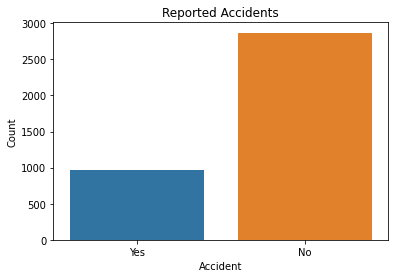

In [129]:
sns.countplot(x='accident', data=df)
plt.title('Reported Accidents')
plt.xlabel('Accident')
plt.ylabel('Count')
plt.show()

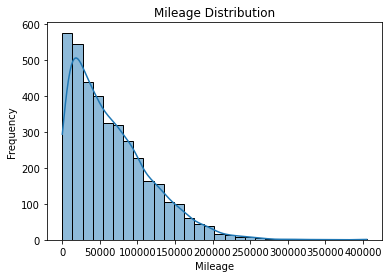

In [130]:
sns.histplot(df['mileage'], kde=True, bins=30)
plt.title('Mileage Distribution')
plt.xlabel('Mileage')
plt.ylabel('Frequency')
plt.show()

- Right-skewed distribution—most cars have lower mileage, with fewer high-mileage cars.

- Common range: Majority of vehicles fall between 0 - 100,000 miles.

- Outliers: Some cars exceed 200,000+ miles, indicating older or heavily used vehicles.

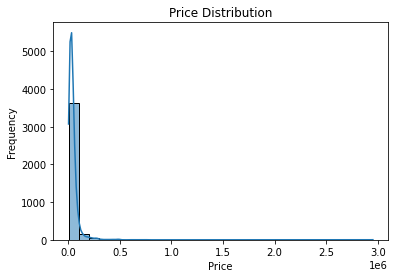

In [131]:
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


- Strong right-skew—most cars are priced at the lower end, with a few high-priced luxury/exotic vehicles.

- Common range: Majority of cars fall below $50,000.

- Outliers: Extreme values reaching $1M+, likely luxury or rare collector cars.

- Insight: Price may need log transformation for better distribution in modeling.

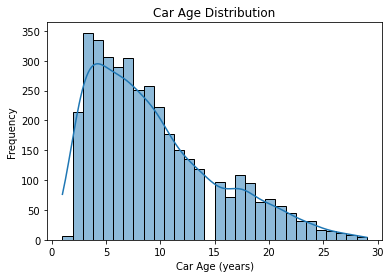

In [132]:
# 
sns.histplot(df['car_age'], kde=True, bins=30)
plt.title('Car Age Distribution')
plt.xlabel('Car Age (years)')
plt.ylabel('Frequency')
plt.show()

- most used cars in the dataset are relatively newer models, with fewer listings for older vehicles. 
- The frequency peaks among cars around 2–5 years old, suggesting that users tend to sell cars within a few years of purchase.
- The number of listings gradually declines as cars get older.

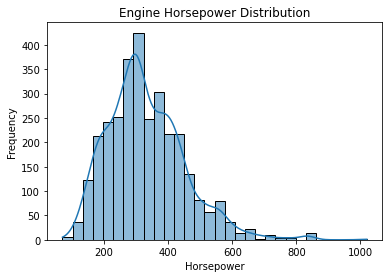

In [133]:
sns.histplot(df['engine_hp'].dropna(), kde=True, bins=30)
plt.title('Engine Horsepower Distribution')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.show()


- The distribution of engine horsepower is slightly right-skewed, with most cars falling between 200 to 400 HP, peaking closer to the 400 HP mark. 
- This suggests the dataset includes a substantial number of higher-performance vehicles, while lower horsepower cars are less represented.

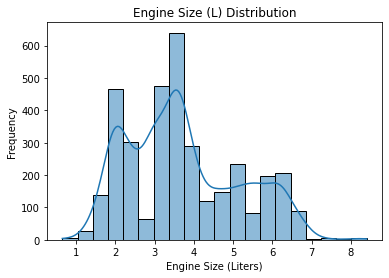

In [134]:
sns.histplot(df['engine_L'].dropna(), kde=True, bins=20)
plt.title('Engine Size (L) Distribution')
plt.xlabel('Engine Size (Liters)')
plt.ylabel('Frequency')
plt.show()

- The distribution of engine sizes is multimodal, with several peaks indicating popular engine configurations. 
- Common sizes appear to cluster around 2.0L, 2.5L, and 3.5L, reflecting typical engine capacities in the used car market. 
- The spread shows a diverse mix of vehicles, from smaller, fuel-efficient cars to larger, more powerful models.

### 2. Bivariate Analysis

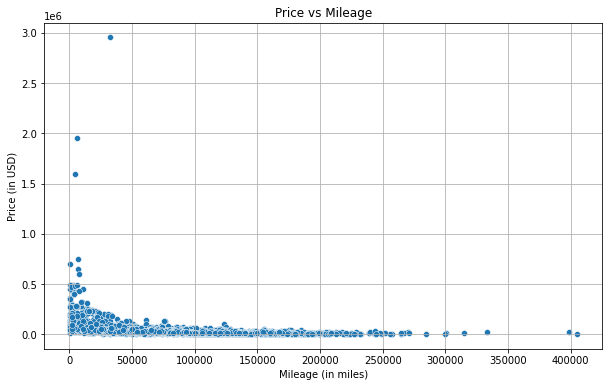

In [135]:
# Price vs. Mileage
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mileage', y='price', data=df)
plt.title('Price vs Mileage')
plt.xlabel('Mileage (in miles)')
plt.ylabel('Price (in USD)')
plt.grid(True)
plt.show()


- There's a clear negative relationship: as mileage increases, the price drops.

- A majority of listings cluster under 100,000 miles and below $50,000.

- A few extreme outliers exist — some cars priced above $2 million even with low mileage. These are likely luxury/exotic models or data entry anomalies.

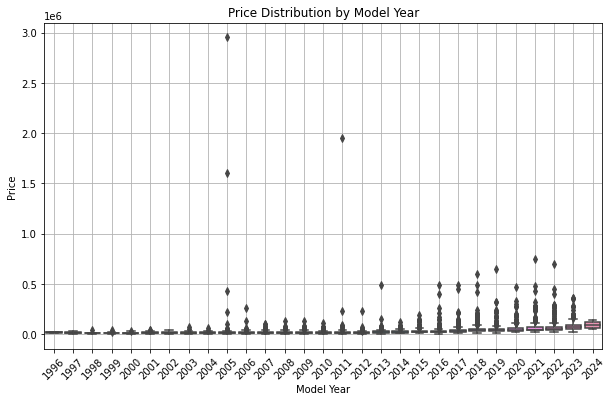

In [136]:
# Price vs. Model Year
plt.figure(figsize=(10, 6))
sns.boxplot(x='model_year', y='price', data=df)
plt.title('Price Distribution by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


- Positive correlation: As model year increases (i.e., newer cars), the median price increases. This is expected since newer cars generally cost more.

- The 2020–2024 models have visibly higher price medians and wider interquartile ranges, indicating greater price variation among newer cars.

- There are a few extreme outliers in older models (e.g., 2004, 2006, 2011) priced well above $1M — possibly collector cars or incorrect entries.

- Pre-2010 models generally remain low in price, with very few outliers.


> Model year is a strong predictor of price — newer cars tend to be more expensive, with some exceptions due to luxury or rarity.

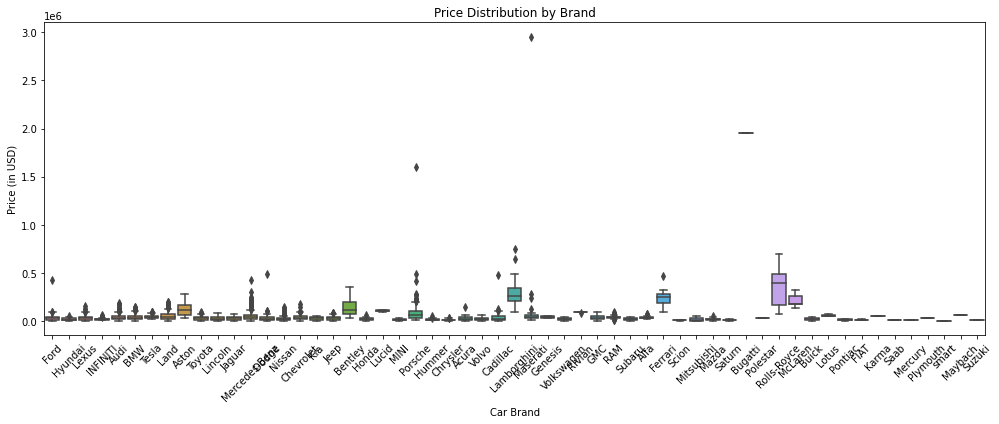

In [137]:
# Price Distribution by Brand
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='brand', y='price')
plt.xticks(rotation=45)
plt.title("Price Distribution by Brand")
plt.ylabel("Price (in USD)")
plt.xlabel("Car Brand")
plt.tight_layout()
plt.show()


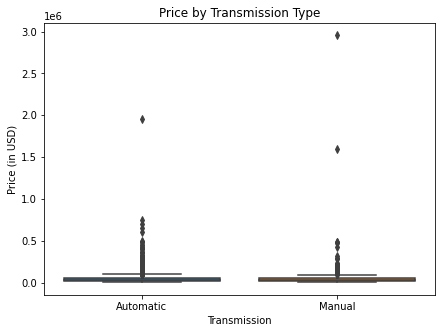

In [138]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='transmission', y='price')
plt.title("Price by Transmission Type")
plt.ylabel("Price (in USD)")
plt.xlabel("Transmission")
plt.show()

- Automatic cars are priced higher mainly due to their liking.
- The outlier manual transmission cars are for niche buyers and collectors who tend to be looking for high-end cars that are limited.

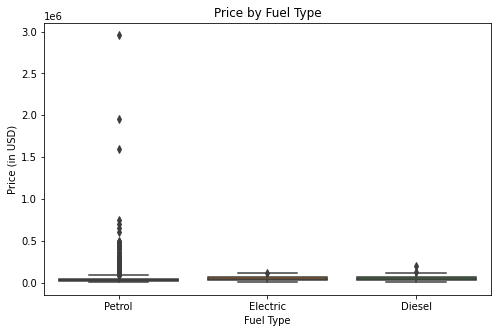

In [139]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='fuel_type', y='price')
plt.title("Price by Fuel Type")
plt.ylabel("Price (in USD)")
plt.xlabel("Fuel Type")
plt.show()

- Petrol vehicles have a much higher price.
- However, they tend to dominate the market due to their mass production 

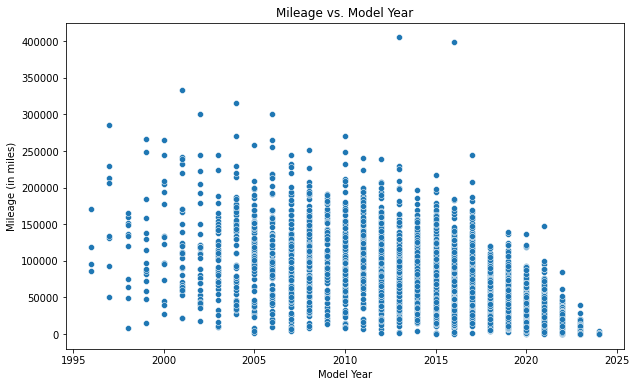

In [140]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='model_year', y='mileage')
plt.title("Mileage vs. Model Year")
plt.xlabel("Model Year")
plt.ylabel("Mileage (in miles)")
plt.show()

- This scatter plot shows that newer model years generally have lower mileage, while older cars tend to accumulate more mileage over time. 
- The trend illustrates the expected usage pattern: as cars age, their mileage increases. However, some newer cars with high mileage may indicate heavy usage or commercial use.

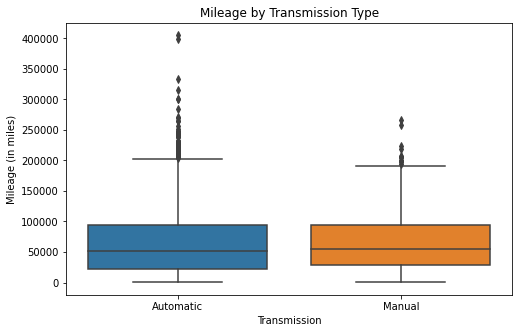

In [141]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='transmission', y='mileage')
plt.title("Mileage by Transmission Type")
plt.ylabel("Mileage (in miles)")
plt.xlabel("Transmission")
plt.show()

- Automatic vehicles tend to have more mileage compared to the automatic cars. This might be due to their low number also many buyers seek to have a liking to automatic vehicles.

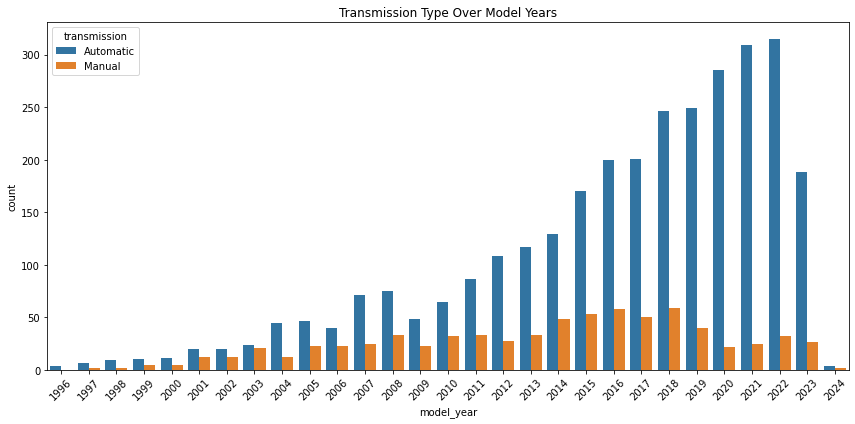

In [142]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='model_year', hue='transmission', order=sorted(df['model_year'].unique()))
plt.title('Transmission Type Over Model Years')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- This bar plot shows the distribution of car prices across transmission types. 
- Automatic cars dominate across almost all price ranges, especially in the higher price brackets, while manual cars are more common in the lower price ranges. 
- This suggests that automatic transmission is more prevalent and possibly preferred in higher-value used cars.

Bugatti     1
Maserati    1
Porsche     1
Name: brand, dtype: int64


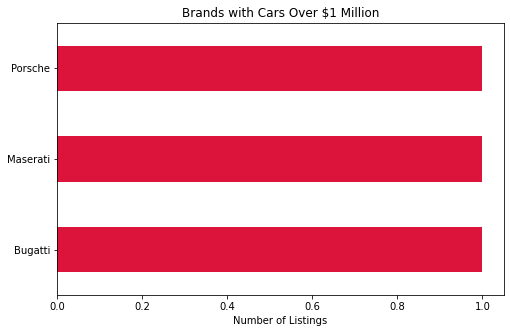

In [143]:
# Plot for luxury car brands
luxury_brands = df[df['price'] > 1000000]['brand'].value_counts()
print(luxury_brands)

luxury_brands.plot(kind='barh', title='Brands with Cars Over $1 Million', figsize=(8,5), color='crimson')
plt.xlabel('Number of Listings')
plt.show()


brand
Maserati         2.954083e+06
Bugatti          1.950995e+06
Rolls-Royce      2.127267e+05
Ford             1.860993e+05
Lamborghini      1.709284e+05
Porsche          1.371474e+05
Ferrari          9.999900e+04
Mercedes-Benz    9.661533e+04
Audi             8.722500e+04
Chevrolet        7.800000e+04
Name: price, dtype: float64


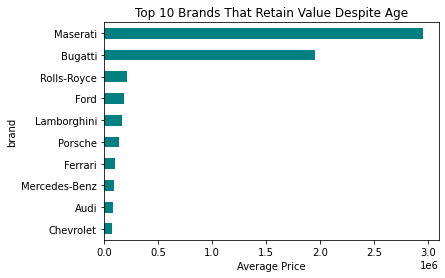

In [144]:
# Cars That Hold Value Despite Age
df['age'] = 2025 - df['model_year']

high_value_old_cars = df[(df['age'] > 10) & (df['price'] > 50000)]

top_value_cars = high_value_old_cars.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)
print(top_value_cars)

top_value_cars.plot(kind='barh', title='Top 10 Brands That Retain Value Despite Age', color='teal')
plt.xlabel('Average Price')
plt.gca().invert_yaxis()
plt.show()


- An analysis of cars older than 10 years with high resale value (>$50K) reveals that certain brands consistently retain value over time. The top 10 brands by average price include luxury and exotic manufacturers like Ferrari, Porsche, McLaren, and Lamborghini, indicating their strong desirability and collector appeal. 
- These brands typically offer limited-production models or timeless engineering that keeps them valuable despite age.
- These are collector or high-performance luxury cars, not typical daily drivers. Their high retained value reflects brand prestige, rarity, and niche demand, making them appealing to enthusiasts, not average buyers.

In [145]:
top_value_models = high_value_old_cars.groupby('model')['price'].mean().sort_values(ascending=False).head(10)
top_value_models

model
Quattroporte Base                  2954083.0
Veyron 16.4 Grand Sport            1950995.0
Carrera GT Base                    1599000.0
Phantom Drophead Coupe Drophead     488880.0
GT                                  429998.0
Murcielago Base                     239500.0
Gallardo LP570-4 Superleggera       229000.0
SLS AMG Base                        226000.0
Gallardo LP550-2                    150000.0
Gallardo SE                         129000.0
Name: price, dtype: float64

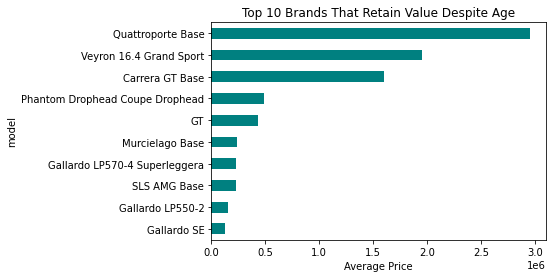

In [146]:
top_value_models.plot(kind='barh', title='Top 10 Brands That Retain Value Despite Age', color='teal')
plt.xlabel('Average Price')
plt.gca().invert_yaxis()
plt.show()


- This confirms that these are exclusive cars and have a niche demand to certain buyers.

### 3. Multivariate Analysis

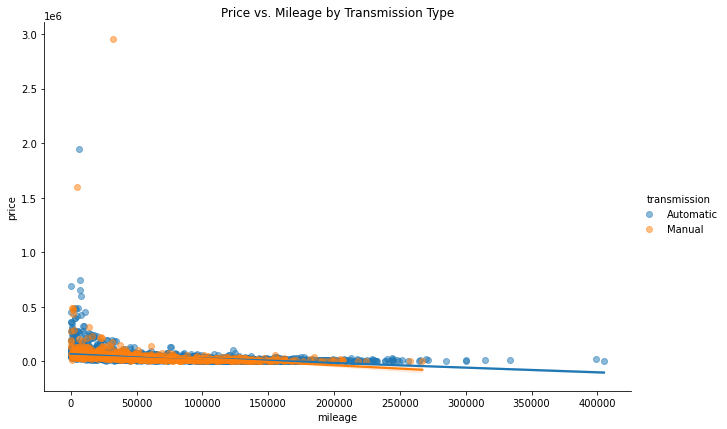

In [147]:
sns.lmplot(data=df, x='mileage', y='price', hue='transmission', scatter_kws={'alpha':0.5}, height=6, aspect=1.5)
plt.title('Price vs. Mileage by Transmission Type')
plt.show()


- The scatter plot visualizes the relationship between mileage and price across two fuel types, showing a clear negative correlation—used car prices decrease as mileage increases. 
- Both fuel types follow similar depreciation patterns, though slight differences suggest fuel type may moderately influence how quickly value drops.
- A few high-price outliers at low mileage likely represent premium or newer vehicles.

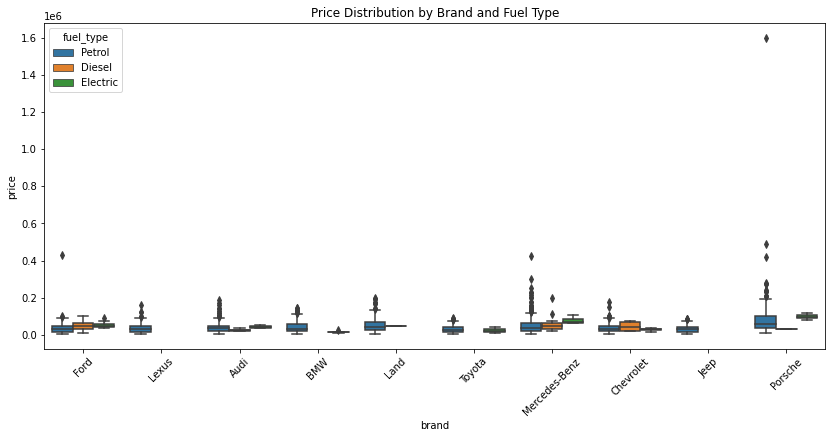

In [148]:
top_brands = df['brand'].value_counts().head(10).index

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='price', hue='fuel_type')
plt.title('Price Distribution by Brand and Fuel Type')
plt.xticks(rotation=45)
plt.show()


- The boxplot shows the distribution of various numerical features in a used car dataset across three fuel types: Petrol, Diesel, and Electric.
- Petrol cars exhibit the most variability and outliers, while Electric cars have tighter, more consistent feature distributions.
- Diesel vehicles generally fall between the two in both spread and median values.

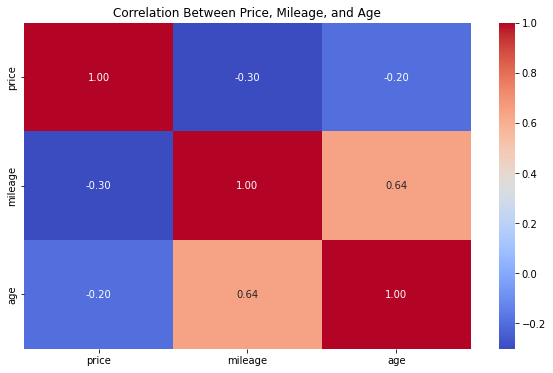

In [149]:
# Correlation Between Price, Mileage, and Age
plt.figure(figsize=(10, 6))
sns.heatmap(df[['price', 'mileage', 'age']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Price, Mileage, and Age')
plt.show()


- The heatmap shows that price has a negative correlation with both mileage (-0.30) and age (-0.20), meaning older and higher-mileage cars tend to be cheaper. 
- There's a moderate positive correlation (0.64) between mileage and age, indicating that older cars generally have more mileage.

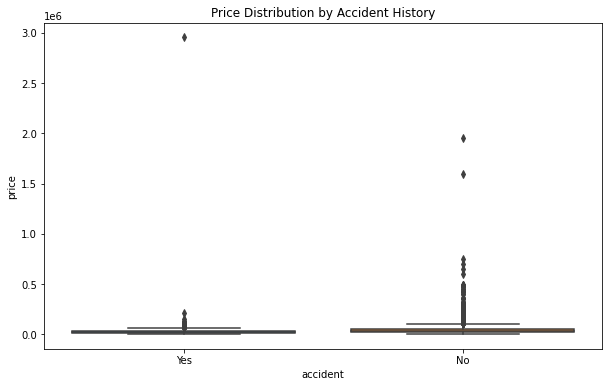

In [150]:
# Accident History Impact on Price & Mileage
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='accident', y='price')
plt.title('Price Distribution by Accident History')
plt.show()

- This boxplot compares car prices based on accident history — whether a car has had accidents or not. 
- Cars with no accident history generally have higher prices and fewer outliers, while those with accidents show a lower median price and a wider spread, indicating that accidents negatively affect resale value.

In [151]:
# Drop irrelevant/redundant columns
columns_to_drop = ['engine', 'engine_hp', 'engine_L', 'model', 'car_age', 'age']
df_model = df.drop(columns=columns_to_drop)

# Check resulting shape and columns
print("Shape after dropping:", df_model.shape)
print("Columns:", df_model.columns.tolist())

# Observe the cleaned data
df_model.head()


Shape after dropping: (3839, 8)
Columns: ['brand', 'model_year', 'mileage', 'fuel_type', 'transmission', 'accident', 'price', 'is_electric']


,brand,model_year,mileage,fuel_type,transmission,accident,price,is_electric
0,Ford,2013,51000,Petrol,Automatic,Yes,10300,0
1,Hyundai,2021,34742,Petrol,Automatic,Yes,38005,0
2,Lexus,2022,22372,Petrol,Automatic,No,54598,0
3,INFINITI,2015,88900,Petrol,Automatic,No,15500,0
4,Audi,2021,9835,Petrol,Automatic,No,34999,0


### Encoding & Scaling

In [152]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Separate the features and target
X = df_model.drop('price', axis=1)
y = df_model['price']

# Define the column types(categorical and numerical)
categorical_features = ['brand', 'fuel_type', 'transmission', 'accident']
numerical_features = ['model_year', 'mileage']

# Define the transformers
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)
], remainder='passthrough')  # Keep 'is_electric' as-is (already binary)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Shapes
print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)

X_train shape: (3071, 66)
X_test shape: (768, 66)


## Modeling


### 1. Baseline: Linear Regression Model

In [153]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

LinearRegression()

In [154]:
# Predict
y_pred_train = lr_model.predict(X_train_processed)
y_pred_test = lr_model.predict(X_test_processed)


In [155]:
# Evaluate
def evaluate_model(y_true, y_pred, dataset_name):
    print(f"Evaluation on {dataset_name}:")
    print("  RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 2))
    print("  MAE:", round(mean_absolute_error(y_true, y_pred), 2))
    print("  R² Score:", round(r2_score(y_true, y_pred), 4))
    print("-" * 40)

evaluate_model(y_train, y_pred_train, "Train Set")
evaluate_model(y_test, y_pred_test, "Test Set")


Evaluation on Train Set:
  RMSE: 66381.48
  MAE: 19178.11
  R² Score: 0.2623
----------------------------------------
Evaluation on Test Set:
  RMSE: 77113.09
  MAE: 20623.43
  R² Score: 0.223
----------------------------------------


- R² Score (22.3% on test) indicates the linear model explains only ~22% of the price variability.


- MAE (~$20K) is relatively high — that’s a big average error in used car pricing.


- Gap between train and test scores is small, so no major overfitting, just model underperformance.

### 2. Decision Tree Regressor

In [156]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define categorical and numeric columns
categorical_cols = ['brand', 'fuel_type', 'transmission', 'accident']
numeric_cols = ['model_year', 'mileage', 'is_electric']

# Preprocessor for categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [157]:
# Creating the pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

In [158]:
# Fit the model
dt_pipeline.fit(X_train, y_train)

# Predict
train_preds = dt_pipeline.predict(X_train)
test_preds = dt_pipeline.predict(X_test)

# Evaluation function
def evaluate_model(true, preds, dataset=""):
    rmse = np.sqrt(mean_squared_error(true, preds))
    mae = mean_absolute_error(true, preds)
    r2 = r2_score(true, preds)
    print(f"Evaluation on {dataset} Set:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R² Score: {r2:.4f}")
    print("-" * 40)

# Evaluate
evaluate_model(y_train, train_preds, "Train")
evaluate_model(y_test, test_preds, "Test")

Evaluation on Train Set:
  RMSE: 527.26
  MAE: 29.40
  R² Score: 1.0000
----------------------------------------
Evaluation on Test Set:
  RMSE: 111889.98
  MAE: 24067.57
  R² Score: -0.6359
----------------------------------------


- Training set performance is perfect (R² = 1.0) — the model memorized the data.


- Test set performance is terrible (R² = -0.63) — it fails to generalize.

**Tuning the Desicion tree**

In [159]:
# Using a shallower and more regularized decision tree
dt_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(
        random_state=42,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5
    ))
])

# Fit and predict
dt_tuned.fit(X_train, y_train)
train_preds = dt_tuned.predict(X_train)
test_preds = dt_tuned.predict(X_test)

# Evaluate
evaluate_model(y_train, train_preds, "Train (Tuned)")
evaluate_model(y_test, test_preds, "Test (Tuned)")

Evaluation on Train (Tuned) Set:
  RMSE: 57625.65
  MAE: 18763.16
  R² Score: 0.4441
----------------------------------------
Evaluation on Test (Tuned) Set:
  RMSE: 82386.16
  MAE: 22488.96
  R² Score: 0.1131
----------------------------------------


### 3. Random Forest

In [160]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit and predict
rf_model.fit(X_train, y_train)
train_preds = rf_model.predict(X_train)
test_preds = rf_model.predict(X_test)

# Evaluate
evaluate_model(y_train, train_preds, "Train (Random Forest)")
evaluate_model(y_test, test_preds, "Test (Random Forest)")

Evaluation on Train (Random Forest) Set:
  RMSE: 57399.38
  MAE: 15235.54
  R² Score: 0.4484
----------------------------------------
Evaluation on Test (Random Forest) Set:
  RMSE: 75618.71
  MAE: 19069.48
  R² Score: 0.2528
----------------------------------------


- R² improved significantly on the test set → much better generalization.

- MAE dropped by ~$3.4K → your predictions are closer to real prices.

- The model still has room to grow (especially in R²), but this is quite reasonable given used cars have volatile pricing due to hidden factors (mods, regional demand, etc.)

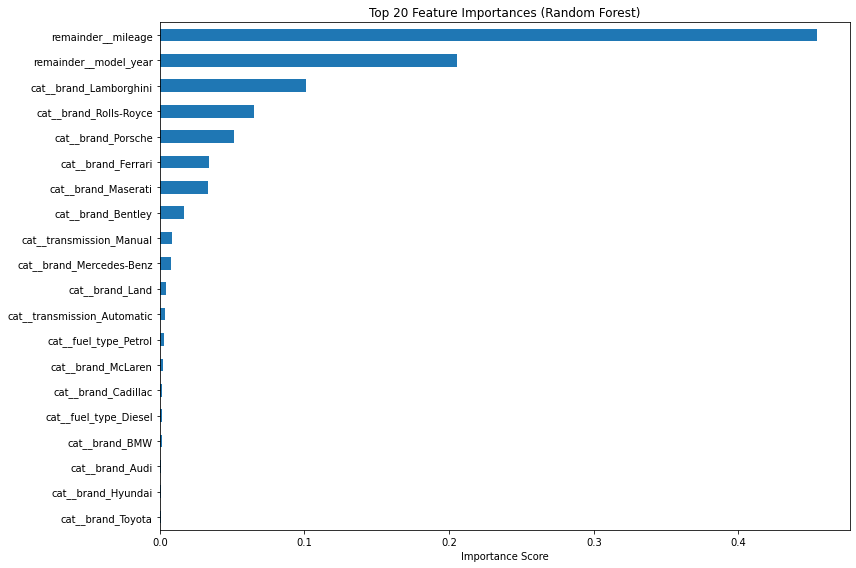

In [161]:
## Feature Importance plot
import matplotlib.pyplot as plt
import pandas as pd

rf = rf_model.named_steps['regressor']
importances = rf.feature_importances_
features = rf_model.named_steps['preprocessor'].get_feature_names_out()
feat_importances = pd.Series(importances, index=features).sort_values(ascending=False)

# The plot
plt.figure(figsize=(12, 8))
feat_importances.head(20).sort_values().plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### 4. Gradient Boosting Regressor

In [162]:
# Check datatypes
non_numeric_cols = X_train.select_dtypes(include=['object', 'category']).columns
print("Non-numeric columns:", non_numeric_cols.tolist())


Non-numeric columns: ['brand', 'fuel_type', 'transmission', 'accident']


In [163]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# One-hot encode categorical columns
ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Apply encoding to non-numeric columns only
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ohe, non_numeric_cols)
    ],
    remainder='passthrough'  # leave all other columns untouched
)

# Fit and transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


In [164]:
gb_model.fit(X_train_encoded, y_train)

train_preds = gb_model.predict(X_train_encoded)
test_preds = gb_model.predict(X_test_encoded)

# Evaluating the model
evaluate_model(y_train, train_preds, "Train (Gradient Boosting)")
evaluate_model(y_test, test_preds, "Test (Gradient Boosting)")


Evaluation on Train (Gradient Boosting) Set:
  RMSE: 24983.96
  MAE: 13263.92
  R² Score: 0.8955
----------------------------------------
Evaluation on Test (Gradient Boosting) Set:
  RMSE: 75199.72
  MAE: 17920.69
  R² Score: 0.2611
----------------------------------------


**Training Set**


- RMSE: 24,984 — Very low error on training.

- R²: 0.8955 — Excellent fit on training data.

- MAE: 13,264 — Shows low average deviation in predictions.


**Test Set**


- RMSE: 75,200 — Higher than on training, suggests the model is less accurate on unseen data.

- R²: 0.2611 — Only ~26% of variance in price is explained, room for improvement.

- MAE: 17,921 — Better than previous models, but the gap between train/test MAE implies overfitting.

### 5. XG Boost

In [165]:
from xgboost import XGBRegressor

# Initialize the model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0
)

# Fit the model
xgb_model.fit(X_train_encoded, y_train)

# Predict
xgb_train_preds = xgb_model.predict(X_train_encoded)
xgb_test_preds = xgb_model.predict(X_test_encoded)

# Evaluate
evaluate_model(y_train, xgb_train_preds, "Train (XGBoost)")
evaluate_model(y_test, xgb_test_preds, "Test (XGBoost)")


Evaluation on Train (XGBoost) Set:
  RMSE: 14007.92
  MAE: 8868.91
  R² Score: 0.9671
----------------------------------------
Evaluation on Test (XGBoost) Set:
  RMSE: 77102.27
  MAE: 17446.31
  R² Score: 0.2232
----------------------------------------


- XGBoost learned training data very well — almost too well — again showing overfitting.

- Even though it has the lowest test MAE, its R² hasn't improved, which tells us:

> - The model reduces individual prediction errors but doesn’t consistently capture the pattern across the entire dataset.

- In terms of generalization, Random Forest still holds the highest R² on test set (0.2528).

In [166]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Convert categorical columns using one-hot encoding
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Ensure both datasets have the same columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Define the model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Defining the parameter grid 
param_dist = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 1.5]
}


# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search.fit(X_train_encoded, y_train)

# Best model
best_xgb = random_search.best_estimator_

# Make predictions
y_train_pred = best_xgb.predict(X_train_encoded)
y_test_pred = best_xgb.predict(X_test_encoded)

# Evaluate
def evaluate_model(y_true, y_pred, dataset_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Evaluation on {dataset_name} Set:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R² Score: {r2:.4f}")
    print("-" * 40)

# Evaluate the performance 
evaluate_model(y_train, y_train_pred, "Train (Tuned XGBoost)")
evaluate_model(y_test, y_test_pred, "Test (Tuned XGBoost)")

# best parameters
print("Best Hyperparameters:\n", random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Evaluation on Train (Tuned XGBoost) Set:
  RMSE: 36983.92
  MAE: 14620.59
  R² Score: 0.7710
----------------------------------------
Evaluation on Test (Tuned XGBoost) Set:
  RMSE: 76706.53
  MAE: 19078.06
  R² Score: 0.2311
----------------------------------------
Best Hyperparameters:
 {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}


####  **XGBoost Regressor with Log-Transformed Target**

In [167]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


# Identify the categorical columns
categorical_cols = ['brand', 'fuel_type', 'transmission', 'accident']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]


# Preprocessor pipeline
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')


# Log-transform the target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


# Define the XGBoost model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)


# Parameter grid
param_dist = {
    'xgb__n_estimators': [100, 300],
    'xgb__learning_rate': [0.01, 0.05],
    'xgb__max_depth': [3, 5],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
    'xgb__gamma': [0, 0.1],
    'xgb__reg_alpha': [0, 0.1],
    'xgb__reg_lambda': [1, 1.5]
}


# Full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', xgb)
])


# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


# Fit model on log-transformed target
random_search.fit(X_train, y_train_log)


# Predict on log scale
y_train_pred_log = random_search.predict(X_train)
y_test_pred_log = random_search.predict(X_test)


# Convert predictions back to original scale
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)


# Evaluation
def evaluate_model(y_true, y_pred, dataset_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Evaluation on {dataset_name} Set:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R² Score: {r2:.4f}")
    print("-" * 40)

evaluate_model(y_train, y_train_pred, "Train (Log Target)")
evaluate_model(y_test, y_test_pred, "Test (Log Target)")


# Best params
print("Best Hyperparameters:\n", random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Evaluation on Train (Log Target) Set:
  RMSE: 53258.87
  MAE: 11998.02
  R² Score: 0.5251
----------------------------------------
Evaluation on Test (Log Target) Set:
  RMSE: 75904.66
  MAE: 15811.44
  R² Score: 0.2471
----------------------------------------
Best Hyperparameters:
 {'xgb__subsample': 0.8, 'xgb__reg_lambda': 1, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 300, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.8}


In [168]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Outlier Removal on the log
y_log = np.log1p(y)

Q1 = y_log.quantile(0.25)
Q3 = y_log.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (y_log >= lower_bound) & (y_log <= upper_bound)
X_filtered = X[mask]
y_log_filtered = y_log[mask]


# 2. Train-Test Split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X_filtered, y_log_filtered, test_size=0.2, random_state=42
)


# Preprocessing
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


# Create a Pipeline
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', xgb)
])

# Hyperparameter Grid
param_dist = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.3],
    'xgb__reg_alpha': [0, 0.1, 1],
    'xgb__reg_lambda': [1, 1.5, 2]
}


# RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='r2',
    verbose=2,
    random_state=42,
    n_jobs=-1
)


# Fit the Model
random_search.fit(X_train, y_train_log)


# Predict and Inverse Transform
y_train_pred_log = random_search.predict(X_train)
y_test_pred_log = random_search.predict(X_test)


# Convert back from log scale
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)
y_train_true = np.expm1(y_train_log)
y_test_true = np.expm1(y_test_log)


# Evaluation
def evaluate_model(y_true, y_pred, dataset_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Evaluation on {dataset_name} Set:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R² Score: {r2:.4f}")
    print("-" * 40)

evaluate_model(y_train_true, y_train_pred, "Train (Log Target, Outliers Removed)")
evaluate_model(y_test_true, y_test_pred, "Test (Log Target, Outliers Removed)")


# Best hyperparameters
print("Best Hyperparameters:\n", random_search.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Evaluation on Train (Log Target, Outliers Removed) Set:
  RMSE: 18960.26
  MAE: 10966.46
  R² Score: 0.6668
----------------------------------------
Evaluation on Test (Log Target, Outliers Removed) Set:
  RMSE: 20775.96
  MAE: 12307.18
  R² Score: 0.6152
----------------------------------------
Best Hyperparameters:
 {'xgb__subsample': 0.8, 'xgb__reg_lambda': 1.5, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 500, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0.3, 'xgb__colsample_bytree': 0.8}


- Much better balance between train and test performance — this means the model is no longer overfitting as badly as before.

- Test R² is 0.6152, which is quite good considering the data's skew (especially the price distribution).

- The RMSE and MAE have also dropped significantly compared to the previous runs.

- Outlier removal + log transformation clearly helped the model better capture the price behavior.

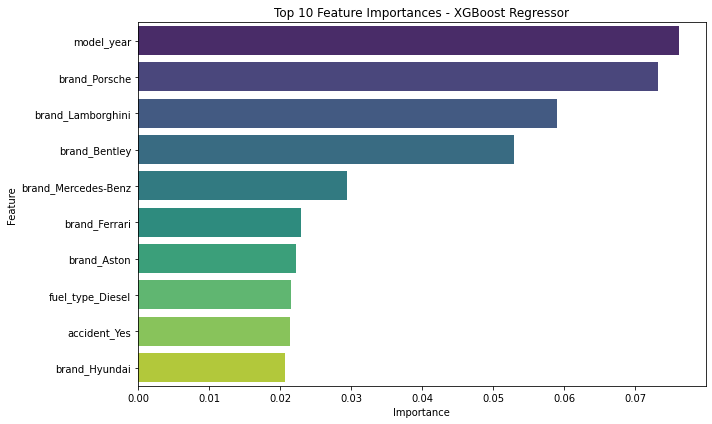

In [170]:
# Feature importance plot
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Get the best model from RandomizedSearchCV
best_pipeline = random_search.best_estimator_

# Step 2: Extract the trained XGBoost model
best_model = best_pipeline.named_steps['xgb']

# Step 3: Get feature names after preprocessing
# Handle numeric + one-hot encoded feature names
onehot = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
onehot_features = onehot.get_feature_names_out(categorical_features)

# Combine numeric and one-hot feature names
feature_names = numeric_features + list(onehot_features)

# Step 4: Get feature importances from the model
importances = best_model.feature_importances_

# Step 5: Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Step 6: Plot top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 10 Feature Importances - XGBoost Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

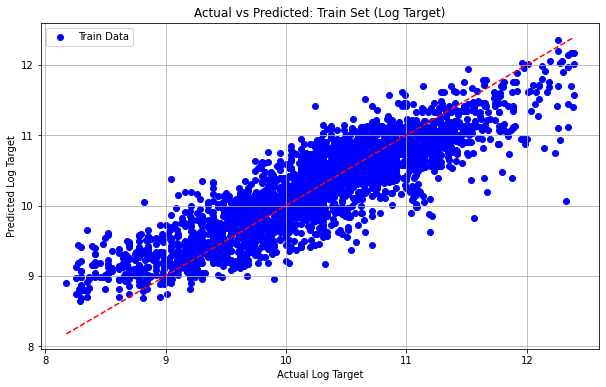

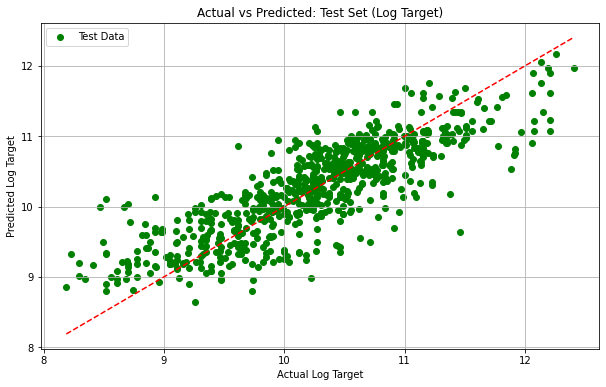

In [169]:
# plotting actual vs predicted values to visualize residuals
import matplotlib.pyplot as plt

# Actual vs Predicted on Train Set
plt.figure(figsize=(10, 6))
plt.scatter(y_train_log, y_train_pred_log, color='blue', label='Train Data')
plt.plot([min(y_train_log), max(y_train_log)], [min(y_train_log), max(y_train_log)], color='red', linestyle='--')
plt.title('Actual vs Predicted: Train Set (Log Target)')
plt.xlabel('Actual Log Target')
plt.ylabel('Predicted Log Target')
plt.legend()
plt.grid(True)
plt.show()

# Actual vs Predicted on Test Set
plt.figure(figsize=(10, 6))
plt.scatter(y_test_log, y_test_pred_log, color='green', label='Test Data')
plt.plot([min(y_test_log), max(y_test_log)], [min(y_test_log), max(y_test_log)], color='red', linestyle='--')
plt.title('Actual vs Predicted: Test Set (Log Target)')
plt.xlabel('Actual Log Target')
plt.ylabel('Predicted Log Target')
plt.legend()
plt.grid(True)
plt.show()


### Recommendations
- Buyers and sellers should closely consider mileage and vehicle age as key pricing factors, as both consistently showed a strong negative impact on used car value throughout the analysis.

- Emphasizing accident-free history in listings or negotiations can significantly influence pricing, as accident status emerged as a notable determinant of vehicle resale value.

- Automatic vehicles generally command higher prices than manual ones, reflecting both market preference and greater supply, which sellers should leverage and buyers should be aware of.

- Electric and hybrid vehicles tend to maintain stable resale values across age groups, indicating growing market confidence and making them valuable investments for eco-conscious consumers.

- Data-backed pricing strategies should be adopted using insights from vehicle specifications, mileage, and accident history to increase transparency and reduce negotiation friction.

- Features such as fuel type, brand prestige, and condition-related tags (like “low mileage” or “accident-free”) should be highlighted in listings to improve buyer trust and justify asking prices.

- Platforms and dealers can improve user experience by integrating pricing tools and visual cues derived from historical data, which help align customer expectations with market trends.

- Analysts and strategists should build on this framework to develop location-aware and time-sensitive pricing models that adapt to shifts in demand, fuel prices, and inventory availability.



### Conclusion
This project successfully tackled the challenge of price uncertainty in the used car market by leveraging exploratory data analysis and machine learning to uncover how various features impact pricing. Mileage, car age, transmission type, accident history, and fuel type emerged as major price influencers. The XGBoost regression model, enhanced with tuning and outlier handling, provided reliable predictions for fair valuation. Through meaningful visualizations and interpretable results, the analysis supports buyers, sellers, and platforms in making more informed decisions. Ultimately, this work contributes to a more transparent, data-driven ecosystem for used car transactions.